# Transport Performance Analysis

On-time delivery, cost-per-route and discrepancy analysis for a B2B/B2C
furniture transport operation. Synthetic dataset modeled on real delivery
rounds (zones, agreed time windows, DDT-style documentation).

**The one thing to keep in mind while reading:** a delivery is not an
isolated event. It is one stop on a round that left the depot at 08:00 or
14:00, and the clock carries over from stop to stop. Most of what follows
comes back to that.

1. On-time rate by zone and customer type
2. Cost per route and per item
3. Discrepancy analysis (what fails, where)
4. B2B vs B2C behaviour

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 4)

df = pd.read_csv(
    "../data/deliveries.csv",
    parse_dates=["delivery_date"],
    # An empty discrepancy_type means "nothing went wrong", not a missing
    # value — without this pandas would turn it into NaN.
    keep_default_na=False,
)

# The CSV stores clock times as text. Rebuild them as datetimes on the
# delivery date, so an arrival can actually be compared with a window.
day = df["delivery_date"].dt.date.astype(str)
df["arrival"] = pd.to_datetime(day + " " + df["arrival_time"])
df["w_start"] = pd.to_datetime(day + " " + df["window_start"])
df["w_end"] = pd.to_datetime(day + " " + df["window_end"])

df["on_time"] = (df["arrival"] >= df["w_start"]) & (df["arrival"] <= df["w_end"])
df["late_minutes"] = (df["arrival"] - df["w_end"]).dt.total_seconds() / 60
df["slot"] = df["route_id"].str[-5:-3]  # "AM" or "PM", from 2026-01-07-AM-V1

print(
    f"{len(df):,} deliveries · {df['route_id'].nunique():,} routes · "
    f"{df['delivery_date'].min().date()} → {df['delivery_date'].max().date()}"
)
df.head(3)

4,593 deliveries · 769 routes · 2026-01-07 → 2026-07-05


,delivery_id,delivery_date,route_id,stop_seq,zone,customer_type,n_items,distance_km,window_start,window_end,arrival_time,discrepancy_type,transport_cost_eur,arrival,w_start,w_end,on_time,late_minutes,slot
0,20001,2026-01-07,2026-01-07-AM-V1,1,RA-province,B2B,3,44,08:00,10:00,08:55,,40.94,2026-01-07 08:55:00,2026-01-07 08:00:00,2026-01-07 10:00:00,True,-65.0,AM
1,20002,2026-01-07,2026-01-07-AM-V1,2,RA-province,B2C,1,16,08:00,12:00,09:17,,40.94,2026-01-07 09:17:00,2026-01-07 08:00:00,2026-01-07 12:00:00,True,-163.0,AM
2,20003,2026-01-07,2026-01-07-AM-V1,3,RA-province,B2C,2,42,08:00,12:00,09:41,,40.94,2026-01-07 09:41:00,2026-01-07 08:00:00,2026-01-07 12:00:00,True,-139.0,AM


## 1. On-time rate

On-time means the van arrived inside the window agreed with the customer:
`window_start <= arrival <= window_end`. The target the office promises when
it books a delivery is 90%.

Overall on-time rate: 88.0%
When late, the median delay past the window is 23 min

zone
FE             72.2%
BO             77.4%
RN             79.6%
FC             82.3%
RA-province    91.4%
RA-city        97.4%


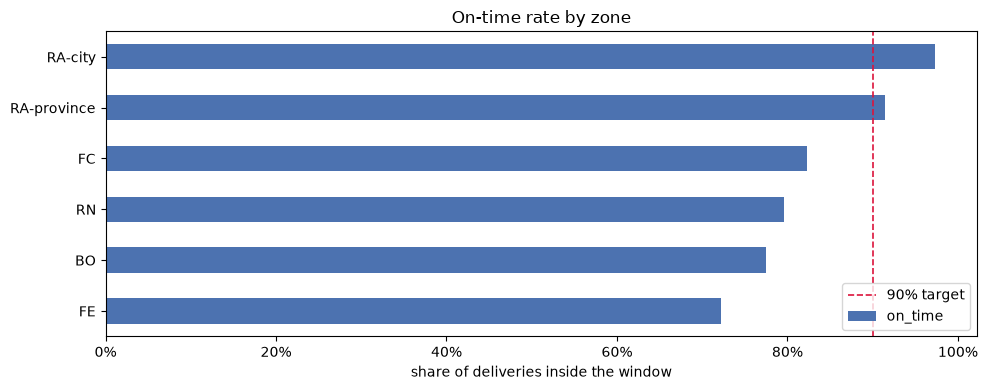

In [2]:
overall = df["on_time"].mean()
median_delay = df.loc[~df["on_time"], "late_minutes"].median()
by_zone = df.groupby("zone")["on_time"].mean().sort_values()

print(f"Overall on-time rate: {overall:.1%}")
print(f"When late, the median delay past the window is {median_delay:.0f} min\n")
print(by_zone.map("{:.1%}".format).to_string())

ax = by_zone.plot.barh(color="#4c72b0")
ax.axvline(0.90, color="crimson", linestyle="--", linewidth=1.2, label="90% target")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set(title="On-time rate by zone", xlabel="share of deliveries inside the window", ylabel="")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Only the two Ravenna zones clear the target. Distance is the obvious
suspect, but it is worth checking *who* is being missed before blaming the
map.

In [3]:
# The average by customer type says the two are basically equivalent...
print(df.groupby("customer_type")["on_time"].mean().map("{:.1%}".format).to_string())

# ...but splitting by zone as well tells a different story.
by_zone_customer = df.pivot_table(index="zone", columns="customer_type", values="on_time")
print("\n", by_zone_customer.map("{:.1%}".format).to_string(), sep="")

customer_type
B2B    87.0%
B2C    88.5%

customer_type    B2B    B2C
zone                       
BO             68.4%  81.0%
FC             81.8%  82.5%
FE             61.0%  75.7%
RA-city        98.7%  96.8%
RA-province    92.9%  90.8%
RN             72.2%  82.9%


B2B is the *best* served customer near the depot and the *worst* served far
from it — the overall average hides both. The reason is in the data: shops
get a 2h window (someone has to be at the goods-in door) while private
addresses get 4h. A narrow window survives a short drive and does not
survive a long one.

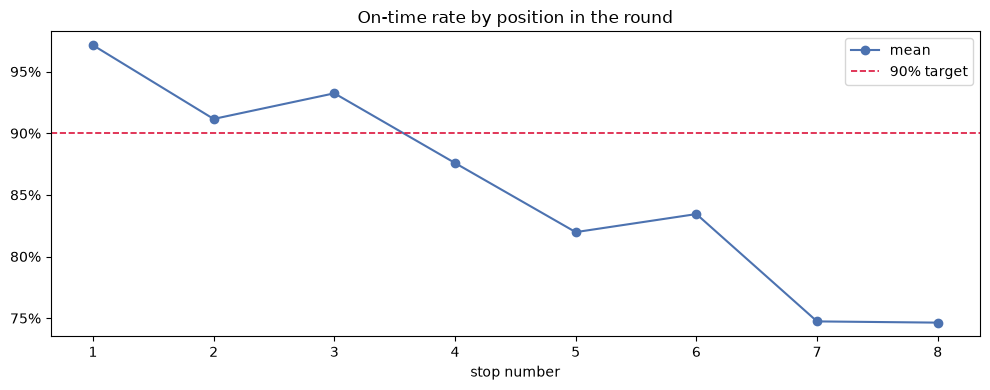

slot
AM    90.4%
PM    85.6%


In [4]:
# And here is the mechanism itself: position in the round.
by_seq = df.groupby("stop_seq")["on_time"].agg(["mean", "size"])
by_seq = by_seq[by_seq["size"] >= 50]  # drop the rare 9-stop tail, too few rows to read

ax = by_seq["mean"].plot(marker="o", color="#4c72b0")
ax.axhline(0.90, color="crimson", linestyle="--", linewidth=1.2, label="90% target")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set(title="On-time rate by position in the round", xlabel="stop number", ylabel="")
ax.legend()
plt.tight_layout()
plt.show()

# Same effect one level up: the afternoon round inherits the morning's delay.
print(df.groupby("slot")["on_time"].mean().map("{:.1%}".format).to_string())

## 2. Cost per route and per item

A round is a joint cost: the van and the driver are paid for the half-day
whether they do four stops or eight, so `transport_cost_eur` is the cost of
the whole route split evenly across its stops. That makes the per-delivery
figure sensitive to how full the round is, not only to how far it goes.

In [5]:
df["cost_per_item"] = df["transport_cost_eur"] / df["n_items"]

cost = df.groupby("zone").agg(
    cost_per_delivery=("transport_cost_eur", "mean"),
    cost_per_item=("cost_per_item", "mean"),
    items_per_delivery=("n_items", "mean"),
    km_from_depot=("distance_km", "mean"),
)
# Stops per route: deliveries in the zone divided by the routes that served it.
cost["stops_per_route"] = df.groupby("zone")["route_id"].agg(lambda s: len(s) / s.nunique())
cost = cost.sort_values("cost_per_delivery")

print(cost.round(2).to_string())

             cost_per_delivery  cost_per_item  items_per_delivery  km_from_depot  stops_per_route
zone                                                                                             
RA-city                  22.23           9.33                3.41          12.65             7.54
RA-province              31.24          13.52                3.41          30.41             6.48
FC                       37.88          16.43                3.39          42.97             5.98
RN                       47.41          11.68                5.05          61.98             4.98
BO                       55.10          13.91                4.83          69.04             4.50
FE                       66.60          17.33                4.63          83.86             4.06


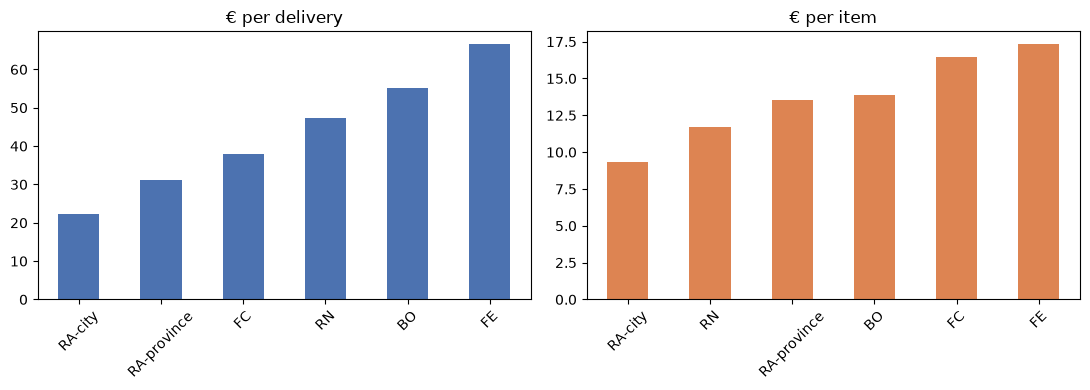

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cost["cost_per_delivery"].plot.bar(ax=axes[0], color="#4c72b0", title="€ per delivery")
cost["cost_per_item"].sort_values().plot.bar(ax=axes[1], color="#dd8452", title="€ per item")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**RN is where the ranking flips.** It costs 25% more per delivery than FC
(€47.41 against €37.88) and 29% *less* per item (€11.68 against €16.43) —
you do not drive to Rimini for one bedside table, so those rounds go out
consolidated: ~5.1 pieces a stop against ~3.4 in FC.

Normalised per item, the worst zone is **FC**: the same small orders as the
city, three times the drive, nothing to spread the fixed half-day cost over.
Distance sets the cost of a *round*; load size sets the cost of a *piece*.

## 3. Discrepancies

Missing item, transport damage, wrong address, refused: whatever the driver
has to write on the DDT before leaving.

203 deliveries with a discrepancy — 4.42% of the total

discrepancy_type
missing_item        96
transport_damage    64
wrong_address       28
refused             15


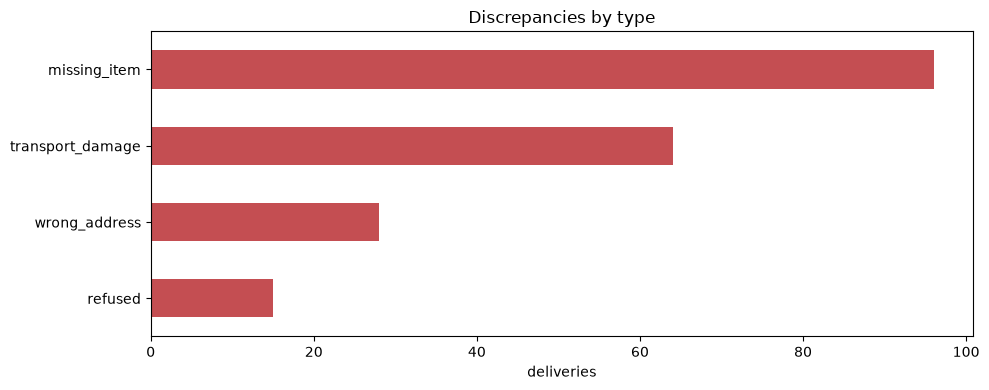

In [7]:
df["has_discrepancy"] = df["discrepancy_type"] != ""
disc = df[df["has_discrepancy"]]

print(f"{len(disc)} deliveries with a discrepancy — {len(disc) / len(df):.2%} of the total\n")

counts = disc["discrepancy_type"].value_counts()
print(counts.to_string())

ax = counts.sort_values().plot.barh(color="#c44e52")
ax.set(title="Discrepancies by type", xlabel="deliveries", ylabel="")
plt.tight_layout()
plt.show()

In [8]:
# Where they happen. Counts first — but read them as rates, because RA-city
# leads the table mostly for having a third of all the deliveries.
print(pd.crosstab(disc["zone"], disc["discrepancy_type"]).to_string())

print("\nDiscrepancy rate by zone:")
print(df.groupby("zone")["has_discrepancy"].mean().sort_values().map("{:.2%}".format).to_string())

discrepancy_type  missing_item  refused  transport_damage  wrong_address
zone                                                                    
BO                          13        1                 7              1
FC                          16        2                12              4
FE                           6        2                 9              2
RA-city                     33        5                15             15
RA-province                 21        4                14              5
RN                           7        1                 7              1

Discrepancy rate by zone:
zone
BO             3.91%
RA-province    4.02%
RA-city        4.38%
FC             4.74%
RN             5.02%
FE             5.51%


In [9]:
# For whom — overall, and then split by type as a share of that customer's
# own deliveries, which is the only way the two are comparable.
by_customer = df.groupby("customer_type")["has_discrepancy"].agg(["sum", "size", "mean"])
print(by_customer.assign(mean=by_customer["mean"].map("{:.2%}".format)).to_string())

rate_by_type = pd.crosstab(df["customer_type"], df["discrepancy_type"], normalize="index")
print("\n", rate_by_type.drop(columns="").map("{:.2%}".format).to_string(), sep="")

# Against order size. Three buckets and not the raw n_items, because above 8
# pieces there are only a few dozen deliveries and the rate jumps on noise.
size_bucket = pd.cut(df["n_items"], [0, 3, 6, 10], labels=["1-3 items", "4-6 items", "7-10 items"])
by_size = df.groupby(size_bucket, observed=True)["has_discrepancy"].agg(["mean", "size"])
print("\n", by_size.assign(mean=by_size["mean"].map("{:.2%}".format)).to_string(), sep="")

               sum  size   mean
customer_type                  
B2B             74  1358  5.45%
B2C            129  3235  3.99%

discrepancy_type missing_item refused transport_damage wrong_address
customer_type                                                       
B2B                     2.87%   0.88%            1.62%         0.07%
B2C                     1.76%   0.09%            1.30%         0.83%

             mean  size
n_items                
1-3 items   3.98%  2264
4-6 items   4.81%  1807
7-10 items  4.98%   522


`missing_item` alone is 47% of the cases, and the rate does climb with the
size of the order (4.0% on 1-3 pieces against ~4.9% above that). That is
what puts B2B (5.4%) above B2C (4.0%): a shop restock carries twice the
lines of a home delivery, and each line is a chance to be short one. It
reads as a per-line risk, so the lever is a line-by-line check at loading,
not more care on the road.

What it does **not** track is distance — BO is the cleanest zone at 3.9%
from 69 km out, cleaner than RA-city at 4.4%. The one type with a
geography of its own is `wrong_address`, which is a B2C problem almost by
definition: nobody loses a shop. Treat the zone crosstab above as
descriptive only — several of its cells are in the single digits.

## 4. B2B vs B2C

The three KPIs side by side — and the caveat that section 1 already earned.

In [10]:
summary = df.groupby("customer_type").agg(
    deliveries=("delivery_id", "size"),
    items_per_delivery=("n_items", "mean"),
    on_time=("on_time", "mean"),
    cost_per_item=("cost_per_item", "mean"),
    discrepancy_rate=("has_discrepancy", "mean"),
)
print(summary.round(3).to_string())

# The on_time column above is the one not to quote on its own.
print("\nOn-time, B2B only, by zone:")
b2b = df[df["customer_type"] == "B2B"]
print(b2b.groupby("zone")["on_time"].mean().sort_values().map("{:.1%}".format).to_string())

               deliveries  items_per_delivery  on_time  cost_per_item  discrepancy_rate
customer_type                                                                          
B2B                  1358               5.873    0.870          6.492             0.054
B2C                  3235               2.909    0.885         15.395             0.040

On-time, B2B only, by zone:
zone
FE             61.0%
BO             68.4%
RN             72.2%
FC             81.8%
RA-province    92.9%
RA-city        98.7%


## Conclusions

- **The punctuality problem is not "the far zones", it is B2B in the far
  zones.** Overall on-time is 88.0%, and B2B looks healthy at 87.0% — but
  split by zone, shops in FE/BO/RN sit at 61-72% while shops in Ravenna
  city are at 98.7%. A 2h goods-in window is not compatible with a 60+ km
  outbound leg followed by a second stop.
- **The fix is scheduling, not driving faster.** On-time falls with the
  position in the round (97% at the first stop, 75% by the seventh) and the
  afternoon slot runs ~5 points below the morning because it starts with
  the morning's delay. Two cheap levers: put far-zone shops first on a
  dedicated early run, and stop promising 2h beyond ~50 km — quote 4h and
  hit it.
- **Next analysis step.** Per item, the expensive zone is FC (€16.43), not
  the far ones: the same 3.4-piece orders as the city, three times the
  drive. Worth testing whether consolidating FC into fewer, fuller rounds
  pays for itself — it would cut cost per item *and* shorten the rounds
  that are missing their windows. That needs the order date (how long a
  customer would have to wait for a fuller round), which this dataset does
  not carry yet.